# 22 — View the seven-class SBM result

Show delta, vega and curvature across all seven formal SBM risk classes.

The three CSR classes remain separate. A zero means no applicable charge for that measure in this synthetic book, not removal of the class.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

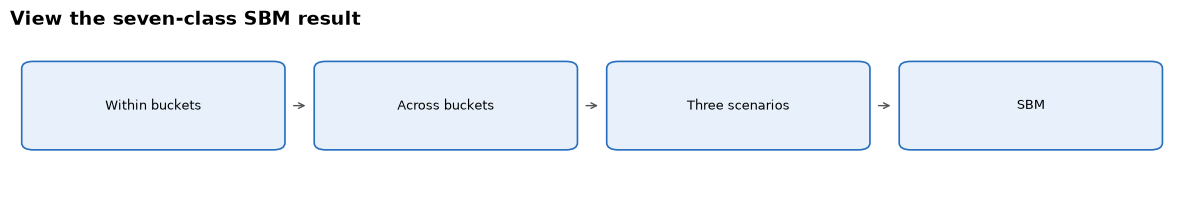

In [2]:
draw_flow(['Within buckets', 'Across buckets', 'Three scenarios', 'SBM'],'View the seven-class SBM result',wrap_after=4)

Add the selected scenario's 21 risk-class-by-measure capital cells to obtain total SBM.

$$SBM_{scenario}=\sum_{class}(K^{delta}+K^{vega}+K^{curvature})$$

In [3]:
classes=pd.read_csv(RUN/'09_sbm_class_results.csv')
scenarios=pd.read_csv(RUN/'10_sbm_scenarios.csv')
selected=scenarios.loc[scenarios.sbm_capital.idxmax(),'scenario']
view=classes[classes.scenario==selected].copy()
pivot=view.pivot(index='risk_class',columns='risk_measure',values='capital').fillna(0)/INR_CRORE
display(pivot.rename_axis(None).rename_axis(None,axis=1))
print(f'Selected scenario: {selected}')
print(f'Total SBM: INR {view.capital.sum()/INR_CRORE:,.4f} crore')

,CURVATURE,DELTA,VEGA
COMMODITY,0.6481,30.9051,3.0302
CSR_NON_SECURITISATION,0.0332,4.1478,1.1099
CSR_SECURITISATION_CTP,0.0000,2.4078,0.0000
CSR_SECURITISATION_NON_CTP,0.0000,0.1513,0.0000
EQUITY,2.2153,26.2840,1.4547
FX,0.0000,14.3437,0.6745
GIRR,0.0000,2.9803,1.1094


Selected scenario: high
Total SBM: INR 91.4954 crore


The visual below uses the calculated rows shown above.

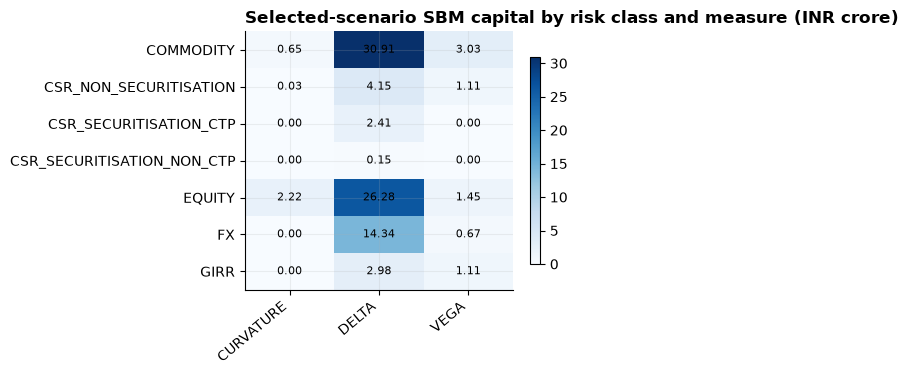

In [4]:
heatmap(pivot,'Selected-scenario SBM capital by risk class and measure (INR crore)',value_format=',.2f')

This completes SBM; default and residual risk are calculated separately.